# B747 Pitch Tracking using LQI Controller

This notebook formulates and solves an optimal control problem for pitch angle tracking in a Boeing 747 aircraft using a Linear Quadratic Integral (LQI) controller. The LQI extends the LQR by adding integral action to eliminate steady-state tracking errors.

The model is derived from the state-space representation of the B747 longitudinal dynamics as provided in the research paper. We minimize the quadratic cost function:

$$
J = \int_0^\infty \left( \mathbf{x}^T Q \mathbf{x} + u^T R u \right) dt
$$

augmented with an integral state for reference tracking.

We use NumPy and SciPy to solve the Algebraic Riccati Equation (ARE) and simulate the closed-loop system.

> **Reference:**  Chrif, L., Kadda, Z. M., & Mohammed, L. (2020). LQR Controller and Optimal Estimation-Observer Design Applied for Pitch Aircraft B747 LQR Controller and Optimal Estimation-Observer Design Applied for Pitch Aircraft B747. *Int. J. Syst. Signal Control Eng. Appl,* 13(3), 53-58. 
> [Download PDF](https://makhillpublications.co/files/published-files/mak-ijsscea/2020/3-53-58.pdf)

<a id="table-of-contents"></a>
## Table of Contents
- [B747 Pitch Tracking using LQI Controller](#b747-pitch-tracking-using-lqi-controller)
  - [Imports](#imports)
  - [System Model](#system-model)
- [LQI Controller Design](#lqi-controller-design)
  - [Augmented system](#augmented-system)
  - [Closed-Loop Simulation](#closed-loop-simulation)
  - [Results Analysis](#results-analysis)


## Imports

In [1]:
import numpy as np
from scipy.linalg import solve_continuous_are
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import pandas as pd

from IPython.display import display, Markdown, HTML, HTML


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## System Model

The state-space model for the pitch dynamics (short-period approximation) is:

States $\mathbf{x} = [w, q, \theta]^T$ (vertical speed, pitch rate, pitch angle)
Input $u = \delta_e$ (elevator deflection)
Output $y = \theta$

From the paper:
$$ A = \begin{bmatrix} -0.3149 & 235.8928 & 0 \\ -0.0034 & -0.4282 & 0 \\ 0 & 1 & 0 \end{bmatrix}, \quad B = \begin{bmatrix} 5.5079 \\ -0.0021 \\ 0 \end{bmatrix}, \quad C = \begin{bmatrix} 0 & 0 & 1 \end{bmatrix} $$

In [2]:
A = np.array([[-0.3149, 235.8928, 0], [-0.0034, -0.4282, 0], [0, 1, 0]])
B = np.array([[5.5079], [-0.0021], [0]])
C = np.array([0, 0, 1]).reshape(1, -1)
n = A.shape[0]

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

# LQI Controller Design

To enable reference tracking without steady-state error, augment the system with an integral state $e_i = \int (r - y) dt$


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Augmented system

$$ \dot{\mathbf{x}}_{aug} = A_{aug} \mathbf{x}_{aug} + B_{aug} u, \quad A_{aug} = \begin{bmatrix} A & \mathbf{0} \\ -C & 0 \end{bmatrix}, \quad B_{aug} = \begin{bmatrix} B \\ 0 \end{bmatrix} $$

Choose cost matrices $Q_{aug}$ (penalizing states and integral error) and $(R)$ (penalizing control effort). Solve the *ARE* for $P$:

$$ A_{aug}^T P + P A_{aug} - P B_{aug} R^{-1} B_{aug}^T P + Q_{aug} = 0 $$

Then, the optimal gain is $$K_{aug} = R^{-1} B_{aug}^T P$$ split into $K_x$ and $K_i$.

In [3]:
# Augment for integral action
A_aug = np.block([[A, np.zeros((n, 1))], [-C, np.array([[0]])]])
B_aug = np.block([[B], [np.array([[0]])]])

# Cost matrices (tune Qi for integral penalty)
Qi = 10.0  # Integral weight
Q_aug = np.diag(
    [1e-3, 1e-3, 1.0, Qi]
)  # Small penalties on w and q, higher on theta and integral
R = np.array([[1.0]])

# Solve ARE
P = solve_continuous_are(A_aug, B_aug, Q_aug, R)

# Optimal gain
K_aug = np.linalg.inv(R) @ B_aug.T @ P
K_x = K_aug[:, :n]  # Gain for states
K_i = K_aug[:, n]  # Gain for integral

# Display gains as a DataFrame for better readability
gains = np.hstack((K_x, K_i.reshape(-1, 1)))
df_gains = pd.DataFrame(gains, columns=['Vertical Speed (w)', 'Pitch Rate (q)', 'Pitch Angle (theta)', 'Integral Error (e_i)'])
df_gains.index = ['Gain']
display(Markdown("### LQI Controller Gains"))
display(
    df_gains.style.set_table_attributes('aria-label="LQI Controller Gains"')
    .set_table_styles([{'selector': 'tr:hover', 'props': [('filter', 'brightness(0.95)')]}])
)


### LQI Controller Gains

,Vertical Speed (w),Pitch Rate (q),Pitch Angle (theta),Integral Error (e_i)
Gain,0.067439,-9.502276,-20.191582,3.162278


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Closed-Loop Simulation

Simulate the augmented system with feedback (u = -K_x \mathbf{x} - K_i e_i).

Reference: step to 0.2 rad (about 11.5°).

In [4]:
def closed_loop_dynamics(xi, t, r):
    x = xi[:n]
    e_i = xi[n]
    u = -K_x @ x - K_i * e_i
    dx = A @ x + B @ u
    de_i = r - C @ x
    return np.hstack((dx.flatten(), de_i.flatten()))


# Initial condition
xi0 = np.zeros(n + 1)

# Time span
t = np.linspace(0, 20, 500)

# Reference pitch
r = 0.2  # rad

# Integrate
xi = odeint(closed_loop_dynamics, xi0, t, args=(r,))

# Extract outputs
theta = xi[:, 2]
# Calculate control input history efficiently
u = -K_x @ xi[:, :n].T - K_i * xi[:, n]
u = u.flatten() # Ensure 1D array



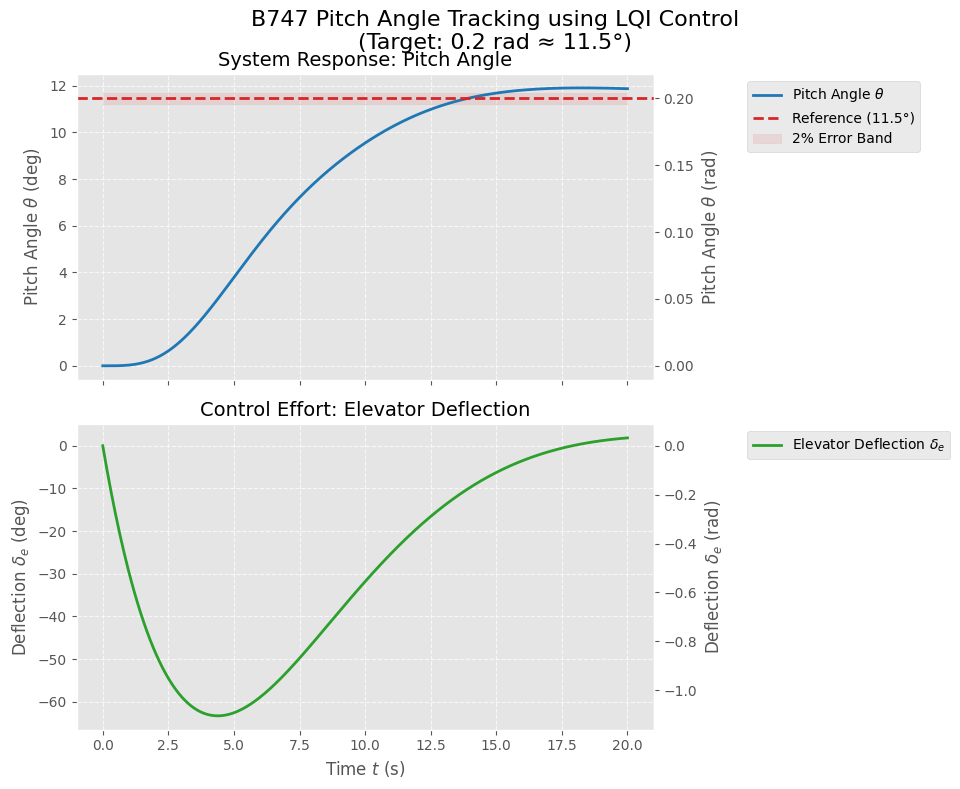

In [5]:
# Visualization
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle(f"B747 Pitch Angle Tracking using LQI Control\n(Target: {r} rad ≈ {np.degrees(r):.1f}°)", fontsize=16)

# Conversion functions for secondary axis
def rad2deg(x):
    return x * 180 / np.pi

def deg2rad(x):
    return x * np.pi / 180

# --- Pitch Angle Plot ---
# Plot in Degrees (Primary Axis)
theta_deg = np.degrees(theta)
r_deg = np.degrees(r)

# Calculate 2% error band
upper_deg = r_deg * 1.02
lower_deg = r_deg * 0.98

axs[0].plot(t, theta_deg, label=r"Pitch Angle $\theta$", linewidth=2, color='tab:blue')
axs[0].axhline(r_deg, color="tab:red", linestyle="--", linewidth=2, label=f"Reference ({r_deg:.1f}°)")

# UX Improvement: Visualize Error Band
axs[0].fill_between(t, lower_deg, upper_deg, color='tab:red', alpha=0.1, label="2% Error Band")

# UX Improvement: Mark Settling Time
# Logic: Last time signal was outside the error band
mask = (theta_deg > upper_deg) | (theta_deg < lower_deg)
if np.any(mask):
    last_idx = np.where(mask)[0][-1]
    if last_idx + 1 < len(t):
        t_settle = t[last_idx + 1]
        # Plot a vertical line
        axs[0].axvline(t_settle, color='green', linestyle=':', linewidth=2, label=f"Settling Time ({t_settle:.2f} s)")
        # Optional: Add a point
        axs[0].plot(t_settle, theta_deg[last_idx+1], 'go')

axs[0].set_ylabel(r"Pitch Angle $\theta$ (deg)", fontsize=12)
axs[0].set_title("System Response: Pitch Angle", fontsize=14)
axs[0].legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=10)
axs[0].grid(True, which='both', linestyle='--', alpha=0.7)

# Secondary Axis (Radians)
secax0 = axs[0].secondary_yaxis('right', functions=(deg2rad, rad2deg))
secax0.set_ylabel(r'Pitch Angle $\theta$ (rad)', fontsize=12)


# --- Control Input Plot ---
# Plot in Degrees (Primary Axis)
u_deg = np.degrees(u)

axs[1].plot(t, u_deg, label=r"Elevator Deflection $\delta_e$", linewidth=2, color='tab:green')
axs[1].set_xlabel(r"Time $t$ (s)", fontsize=12)
axs[1].set_ylabel(r"Deflection $\delta_e$ (deg)", fontsize=12)
axs[1].set_title("Control Effort: Elevator Deflection", fontsize=14)
axs[1].legend(bbox_to_anchor=(1.15, 1), loc='upper left', fontsize=10)
axs[1].grid(True, which='both', linestyle='--', alpha=0.7)

# Secondary Axis (Radians)
secax1 = axs[1].secondary_yaxis('right', functions=(deg2rad, rad2deg))
secax1.set_ylabel(r'Deflection $\delta_e$ (rad)', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.9) # Adjust for suptitle
plt.show()


In [6]:
# --- Performance Metrics ---
def get_step_metrics(t, y, final_target):
    # Calculates rise time, settling time, and overshoot.
    
    try:
        t10_idx = np.argmax(y >= 0.1 * final_target)
        t10 = t[t10_idx]
        
        t90_idx = np.argmax(y >= 0.9 * final_target)
        t90 = t[t90_idx]
        
        rise_time = t90 - t10
    except:
        rise_time = np.nan
    
    # Settling Time (2%)
    # Last time it was outside 2% error band
    upper = final_target * 1.02
    lower = final_target * 0.98
    
    # Indices where signal is outside bounds
    mask = (y > upper) | (y < lower)
    
    if np.any(mask):
        # The last index where it was outside
        last_idx = np.where(mask)[0][-1]
        # Settling time is the time of the *next* sample (where it entered and stayed)
        # or just approximation
        if last_idx + 1 < len(t):
             settling_time = t[last_idx + 1]
        else:
             settling_time = t[-1] # Still not settled
    else:
        settling_time = 0.0 # Started inside?
        
    # Overshoot
    max_val = np.max(y)
    if max_val > final_target:
        overshoot = (max_val - final_target) / final_target * 100
    else:
        overshoot = 0.0
    
    steady_state_error = np.abs(y[-1] - final_target)
    
    return {
        "Rise Time (10-90%)": f"{rise_time:.3f} s",
        "Settling Time (2%)": f"{settling_time:.3f} s",
        "Overshoot": f"{overshoot:.2f}%",
        "Steady-State Error": f"{steady_state_error:.2e}"
    }

# Calculate metrics using simulation results
# Note: 't', 'theta', 'r' must be available from the simulation block above
try:
    metrics = get_step_metrics(t, theta, r)

    # Display
    # Render using HTML table to improve readability and screen reader accessibility
    display(Markdown("### 📊 System Performance Metrics"))
    html_table = "<table aria-label=\"System Performance Metrics\">\n"
    html_table += "  <thead>\n"
    html_table += "    <tr><th scope=\"col\">Metric</th><th scope=\"col\">Value</th></tr>\n"
    html_table += "  </thead>\n"
    html_table += "  <tbody>\n"
    for k, v in metrics.items():
        html_table += f"    <tr><th scope=\"row\">{k}</th><td>{v}</td></tr>\n"
    html_table += "  </tbody>\n</table>"
    display(HTML(html_table))
except NameError as e:
    display(Markdown(f"**Error calculating metrics:** {e}"))


### 📊 System Performance Metrics

Metric,Value
Rise Time (10-90%),8.096 s
Settling Time (2%),20.000 s
Overshoot,3.90%
Steady-State Error,7.19e-03


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Results Analysis

The simulation shows the pitch angle tracking the reference with zero steady-state error due to the integral action. The control input stabilizes after the transient. This demonstrates the optimal tracking performance achieved by solving the LQR problem for the augmented system.

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>